<a href="https://colab.research.google.com/github/Jamesdabrowski7/reddit-api/blob/main/Project_3_James_Dabrowski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# James Dabrowski 1 Project 3
# installing packages
!pip install praw
import praw
import pandas as pd
import requests
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.1 MB/s eta 0:00:00


In [ ]:

# passing details
reddit = praw.Reddit(client_id='_MdWCL_7ORwY7OxSxVyKjA',
                     client_secret='zYp8idfvIryy0kSDxcDJJpvLyA7hgQ',
                     user_agent='James QMSS')

In [ ]:
# scrape Comments
# URL of the post
url = "https://www.reddit.com/r/dataisbeautiful/comments/tnl9le/oc_income_and_wealth_inequality_over_time_in_50/"

# creating a submission object or a submission (post) from the given url
submission = reddit.submission(url=url)


In [ ]:
# including all the comments within comments
post_comments = []  # creating an empty list

submission.comments.replace_more(limit = None)
for comment in submission.comments.list():
  #looping through submission.comments.list() so it will give me comments and their replies
  post_comments.append([comment.body, comment.ups, comment.downs, comment.created]) # append the comment body to the empty list

# creating a dataframe
comments = pd.DataFrame(post_comments, columns=['comment', 'ups', 'downs', 'created'])
comments

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

,comment,ups,downs,created
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09
2,[removed],1347,0,1.648220e+09
3,Can someone explain me what the difference of ...,880,0,1.648219e+09
4,[deleted],2299,0,1.648217e+09
...,...,...,...,...
997,> One way they can avoid the estate tax is to ...,1,0,1.648254e+09
998,I think that’s a fairly big assumption though ...,1,0,1.648256e+09
999,"Yeah, if you’re interested in doing further re...",1,0,1.648254e+09
1000,So who is paying the estate taxes averaging 9 ...,1,0,1.648257e+09


In [ ]:
# converting the created date to what we can easily read

from datetime import datetime

comments['date_time'] = pd.to_datetime(comments['created'],  unit='s')    # this passes all the time details, including time. # The unit specify what unit our int is is away from the origin
comments['date'] = comments['date_time'].dt.strftime('%Y-%m-%d') # now we have created a formatted string, with only the date

comments.head()

,comment,ups,downs,created,date_time,date
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25
2,[removed],1347,0,1.648220e+09,2022-03-25 14:46:54,2022-03-25
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25
4,[deleted],2299,0,1.648217e+09,2022-03-25 13:56:38,2022-03-25


In [ ]:
# remove the duplicates and save data to csv file
comments_1 = comments
comments_1.drop_duplicates(subset='comment', keep='last', inplace=True)
comments_1.to_csv('oscars_comments.csv', index=True, header=True)
comments_1.shape #view dimension of data to see how many data points remain after cleaning

(977, 6)

In [ ]:
# importing some libraries for sentiment analysis
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# download the VADER lexicon if it's not already downloaded
nltk.download('vader_lexicon')

# instantiate the VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

def get_vader_label(text):
    return sid.polarity_scores(text)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# applying sentiment analysis to the data to get scores
comments_1['compund_score'] = comments_1['comment'].apply(get_vader_label)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com..."
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp..."
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com..."
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co..."


In [ ]:
def get_vader_pos(text):
  return sid.polarity_scores(text)['pos']

comments_1['pos_score'] = comments_1['comment'].apply(get_vader_pos)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score,pos_score
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com...",0.146
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",0.197
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com...",0.149
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co...",0.089


In [ ]:
def get_vader_neg(text):
  return sid.polarity_scores(text)['neg']

comments_1['neg_score'] = comments_1['comment'].apply(get_vader_neg)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score,pos_score,neg_score
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com...",0.146,0.064
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",0.197,0.000
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com...",0.149,0.060
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co...",0.089,0.083


In [ ]:
def get_vader_neu(text):
  return sid.polarity_scores(text)['neu']

comments_1['neu_score'] = comments_1['comment'].apply(get_vader_neu)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score,pos_score,neg_score,neu_score
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com...",0.146,0.064,0.790
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",0.197,0.000,0.803
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com...",0.149,0.060,0.791
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000,1.000
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co...",0.089,0.083,0.828


In [ ]:
def get_vader_compound(text):
  return sid.polarity_scores(text)['compound']

comments_1['compound_score'] = comments_1['comment'].apply(get_vader_compound)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score,pos_score,neg_score,neu_score,compound_score
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com...",0.146,0.064,0.790,0.8442
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",0.197,0.000,0.803,0.4019
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com...",0.149,0.060,0.791,0.4404
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000,1.000,0.0000
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co...",0.089,0.083,0.828,0.0516


In [ ]:
# creating a function to classify the polarity
def analyze_sentiment(text):
    if text >= 0.05:
        return 'Positive Sentiment'
    elif text <= -0.05:
        return 'Negative Sentiment'
    else:
        return 'Neutral Sentiment'

In [ ]:
comments_1['sentiment'] = comments_1['compound_score'].apply(analyze_sentiment)
comments_1.head()

,comment,ups,downs,created,date_time,date,compund_score,pos_score,neg_score,neu_score,compound_score,sentiment
0,Thank you for your [Original Content](https://...,1,0,1.648219e+09,2022-03-25 14:32:19,2022-03-25,"{'neg': 0.064, 'neu': 0.79, 'pos': 0.146, 'com...",0.146,0.064,0.790,0.8442,Positive Sentiment
1,Interesting to see that Japan and Germany took...,813,0,1.648219e+09,2022-03-25 14:29:20,2022-03-25,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",0.197,0.000,0.803,0.4019,Positive Sentiment
3,Can someone explain me what the difference of ...,880,0,1.648219e+09,2022-03-25 14:30:33,2022-03-25,"{'neg': 0.06, 'neu': 0.791, 'pos': 0.149, 'com...",0.149,0.060,0.791,0.4404,Positive Sentiment
5,Data: World Inequality Database\n\nTools: RStu...,400,0,1.648213e+09,2022-03-25 12:53:40,2022-03-25,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000,1.000,0.0000,Neutral Sentiment
6,South Africa is omega corrupt. This chart just...,27,0,1.648251e+09,2022-03-25 23:26:39,2022-03-25,"{'neg': 0.083, 'neu': 0.828, 'pos': 0.089, 'co...",0.089,0.083,0.828,0.0516,Positive Sentiment


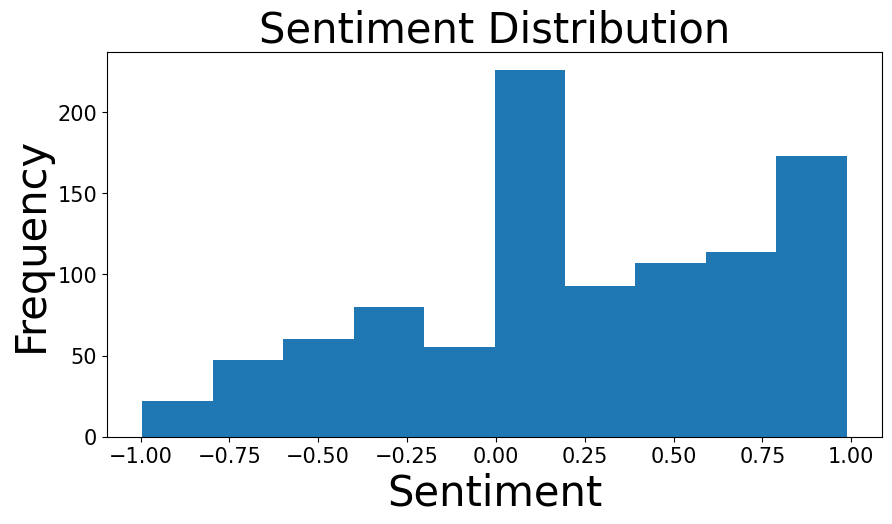

In [ ]:
import matplotlib.pyplot as plt  # importing the pyplot module
# creating bar chart of the sentiment to visualize the data
plt.figure(figsize=(10,5))
plt.xlabel('Sentiment', fontsize=30)
plt.xticks(fontsize=15)
plt.ylabel('Frequency', fontsize=30)
plt.yticks(fontsize=15)
plt.hist(comments_1['compound_score'], bins=10)
plt.title('Sentiment Distribution', fontsize=30)
plt.show()

In [ ]:
# creating columns
# adding a column for the number of characters in each comment
comments_1['num_characters'] = comments_1['comment'].apply(len)

# adding another column for the number of words in each comment
comments_1['num_words'] = comments_1['comment'].apply(lambda x: len(x.split()))

# displaying the updated data
print(comments_1)

                                                comment  ups  downs  \
0     Thank you for your [Original Content](https://...    1      0   
1     Interesting to see that Japan and Germany took...  813      0   
3     Can someone explain me what the difference of ...  880      0   
5     Data: World Inequality Database\n\nTools: RStu...  400      0   
6     South Africa is omega corrupt. This chart just...   27      0   
...                                                 ...  ...    ...   
997   > One way they can avoid the estate tax is to ...    1      0   
998   I think that’s a fairly big assumption though ...    1      0   
999   Yeah, if you’re interested in doing further re...    1      0   
1000  So who is paying the estate taxes averaging 9 ...    1      0   
1001  I think it’s one part of the tax problem, but ...    1      0   

           created           date_time        date  \
0     1.648219e+09 2022-03-25 14:32:19  2022-03-25   
1     1.648219e+09 2022-03-25 14:29:20 

In [ ]:
print(comments_1['sentiment'])


0       Positive Sentiment
1       Positive Sentiment
3       Positive Sentiment
5        Neutral Sentiment
6       Positive Sentiment
               ...        
997     Positive Sentiment
998     Positive Sentiment
999     Positive Sentiment
1000    Positive Sentiment
1001    Positive Sentiment
Name: sentiment, Length: 977, dtype: object


In [ ]:
# filter comments by sentiment and map 'positive' to 1 and 'negative' to 0 in one step
data_filtered = comments_1.loc[comments_1['sentiment'].isin(['Positive Sentiment', 'Negative Sentiment'])].copy()
data_filtered['sentiment_binary'] = data_filtered['sentiment'].map({'Positive Sentiment': 1, 'Negative Sentiment': 0})



In [ ]:
# features and target variables
X = data_filtered[['ups', 'downs', 'num_characters', 'num_words', 'pos_score', 'neg_score', 'neu_score']]
y = data_filtered['sentiment_binary']


In [ ]:
print(data_filtered)

                                                comment  ups  downs  \
0     Thank you for your [Original Content](https://...    1      0   
1     Interesting to see that Japan and Germany took...  813      0   
3     Can someone explain me what the difference of ...  880      0   
6     South Africa is omega corrupt. This chart just...   27      0   
7     What would an economist (or other appropriate ...  123      0   
...                                                 ...  ...    ...   
997   > One way they can avoid the estate tax is to ...    1      0   
998   I think that’s a fairly big assumption though ...    1      0   
999   Yeah, if you’re interested in doing further re...    1      0   
1000  So who is paying the estate taxes averaging 9 ...    1      0   
1001  I think it’s one part of the tax problem, but ...    1      0   

           created           date_time        date  \
0     1.648219e+09 2022-03-25 14:32:19  2022-03-25   
1     1.648219e+09 2022-03-25 14:29:20 

In [ ]:
# splittign data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# importing libraries for machine learning
from sklearn.linear_model import LogisticRegression

# initializing and traiingn model
model = LogisticRegression()
model.fit(X_train, y_train)

# print coeffcients

LogisticRegression()

In [ ]:
# creating a logistic regression model
model = LogisticRegression()

# fiting the model to data
model.fit(X, y)

# getting the coefficients
coefficients = model.coef_[0]

# exponentiate the coefficients
odds_ratios = np.exp(coefficients)

print(odds_ratios)

[1.00239950e+00 1.00000000e+00 1.00046389e+00 1.00142936e+00
 3.17654288e+03 3.05946371e-04 1.03771809e+00]


In [ ]:
# importing libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# making predictions on the test set
y_pred = model.predict(X_test)

# calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# printing the results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.90
Precision: 0.87
Recall: 1.00
F1 Score: 0.93


In [ ]:
# including images/charts to show the data

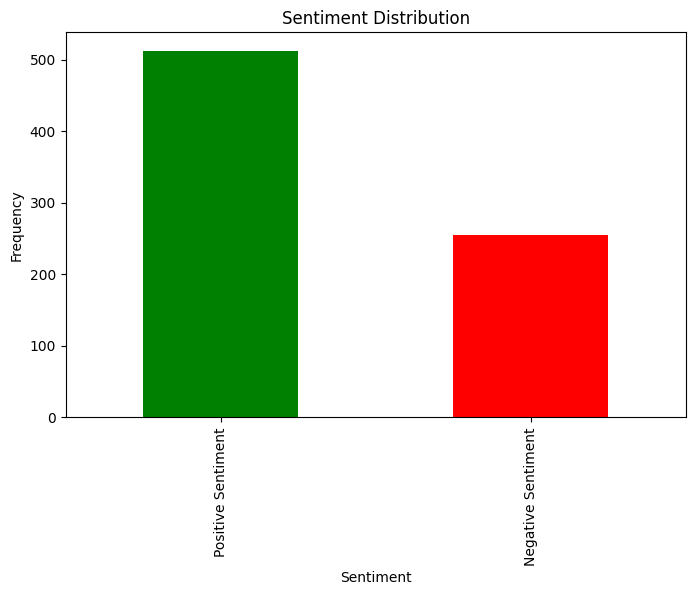

In [ ]:
# bar chart showing pos/neg sentiment
data_filtered['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'], figsize=(8, 5))
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()


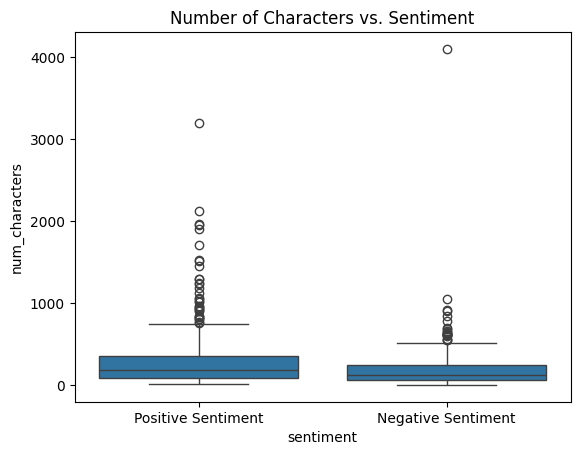

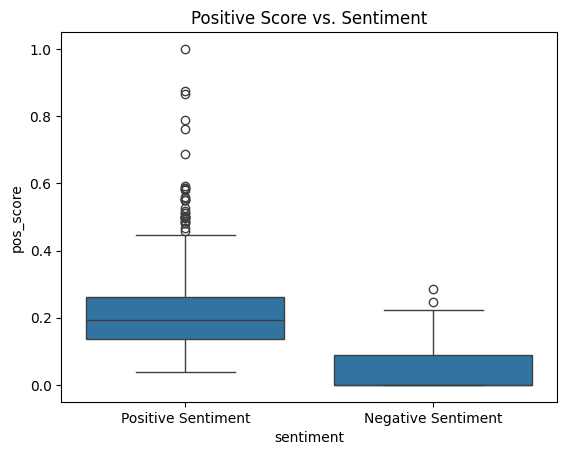

In [ ]:
# box plot

sns.boxplot(x='sentiment', y='num_characters', data=data_filtered)
plt.title('Number of Characters vs. Sentiment')
plt.show()

sns.boxplot(x='sentiment', y='pos_score', data=data_filtered)
plt.title('Positive Score vs. Sentiment')
plt.show()

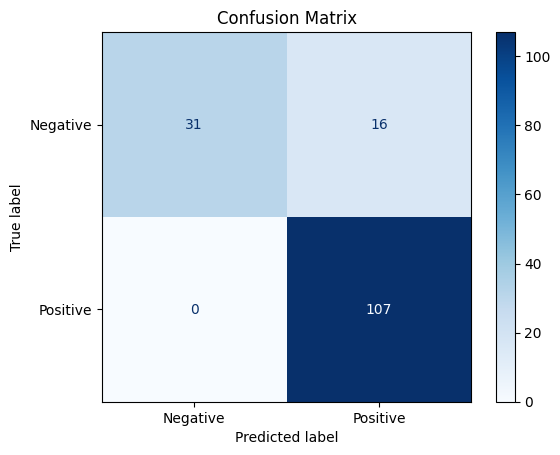

In [ ]:
# creating confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(data_filtered.shape)

(768, 15)
